<a href="https://colab.research.google.com/github/T-Rahman28/Optimization-of-Photonic-Crystal-Nanocavities-using-Computationally-Efficient-Neural-Networks/blob/main/Draft_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import h5py
from torch.utils.data import TensorDataset
import torch.optim as optim

In [ ]:
input_mat_file_path = '/content/Input.mat'
with h5py.File(input_mat_file_path, 'r') as file:
    input_variable_data = file['Input'][:]


output_mat_file_path = '/content/Output.mat'
with h5py.File(output_mat_file_path, 'r') as file:
    output_variable_data = file['QnV'][:]

In [ ]:
print(f'Shape of Input: {input_variable_data.shape}')
print(f'Shape of Output: {output_variable_data.shape}')

Shape of Input: (12, 5, 3, 12500)
Shape of Output: (2, 12500)


**Input data (total of 12,500 samples) has height of 5 pixels, width of 12 pixels with number of channels being 3. Output data has 2 categories, Q-factor (Q) and Modal Volume (V)**

Converting the input and output data into tensor type

In [ ]:
input_tensor = torch.tensor(input_variable_data)
output_tensor = torch.tensor(output_variable_data)

In [ ]:
input_tensor = input_tensor.permute(3,2,1,0).float()
output_tensor = output_tensor.permute(1,0).float()

In [ ]:
print(f'New Input Shape: {input_tensor.shape}')
print(f'New Output Shape: {output_tensor.shape}')

New Input Shape: torch.Size([12500, 3, 5, 12])
New Output Shape: torch.Size([12500, 2])


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


**Plots describing input tensor**

In [ ]:
reshaped_input = input_tensor.reshape(12500, -1)
reshaped_input_numpy = reshaped_input.numpy()


In [ ]:
reshaped_input_numpy.flatten().shape

(2250000,)

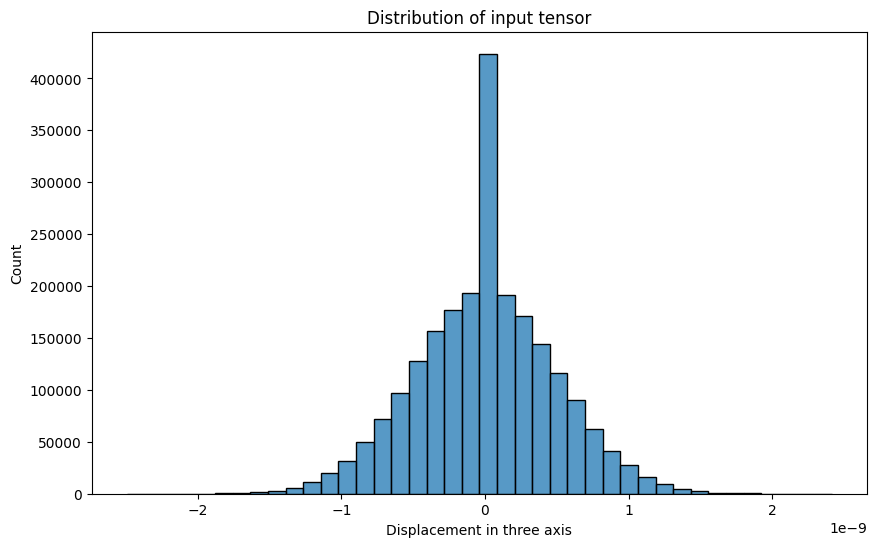

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data = reshaped_input_numpy.flatten(), bins = 40 )
plt.title('Distribution of input tensor')
plt.xlabel('Displacement in three axis')
plt.ylabel('Count')
plt.show()

**Plotting each channel separately**

In [ ]:
channel1_data = input_tensor[:, 0, :, :].unsqueeze(1)  # Extract data from channel 1
channel2_data = input_tensor[:, 1, :, :].unsqueeze(1)  # Extract data from channel 2
channel3_data = input_tensor[:, 2, :, :].unsqueeze(1)  # Extract data from channel 3

In [ ]:
channel1_data_numpy = channel1_data.reshape(12500, -1).numpy()
channel2_data_numpy = channel2_data.reshape(12500, -1).numpy()
channel3_data_numpy = channel3_data.reshape(12500, -1).numpy()

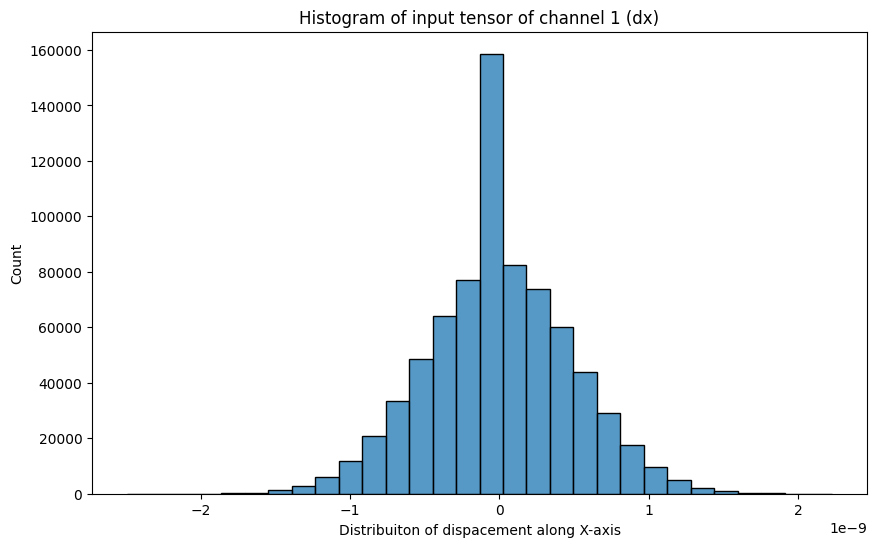

In [ ]:
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=channel1_data_numpy.flatten(), bins=30)
plt.title('Histogram of input tensor of channel 1 (dx)')
plt.xlabel('Distribuiton of dispacement along X-axis')
plt.ylabel('Count')
plt.show()

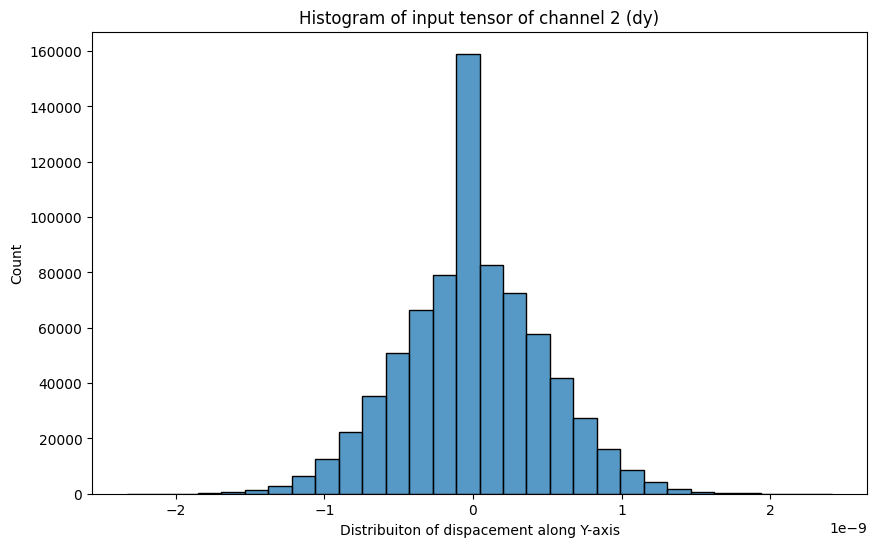

In [ ]:
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=channel2_data_numpy.flatten(), bins=30)
plt.title('Histogram of input tensor of channel 2 (dy)')
plt.xlabel('Distribuiton of dispacement along Y-axis')
plt.ylabel('Count')
plt.show()

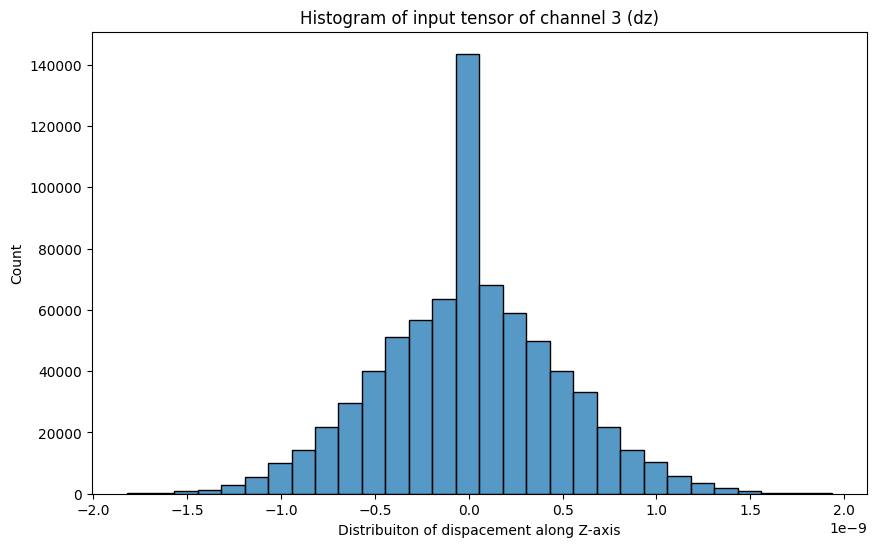

In [ ]:
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=channel3_data_numpy.flatten(), bins=30)
plt.title('Histogram of input tensor of channel 3 (dz)')
plt.xlabel('Distribuiton of dispacement along Z-axis')
plt.ylabel('Count')
plt.show()

In [ ]:
channel1_data_numpy_flat = channel1_data_numpy.flatten()
channel2_data_numpy_flat = channel2_data_numpy.flatten()
channel3_data_numpy_flat = channel3_data_numpy.flatten()

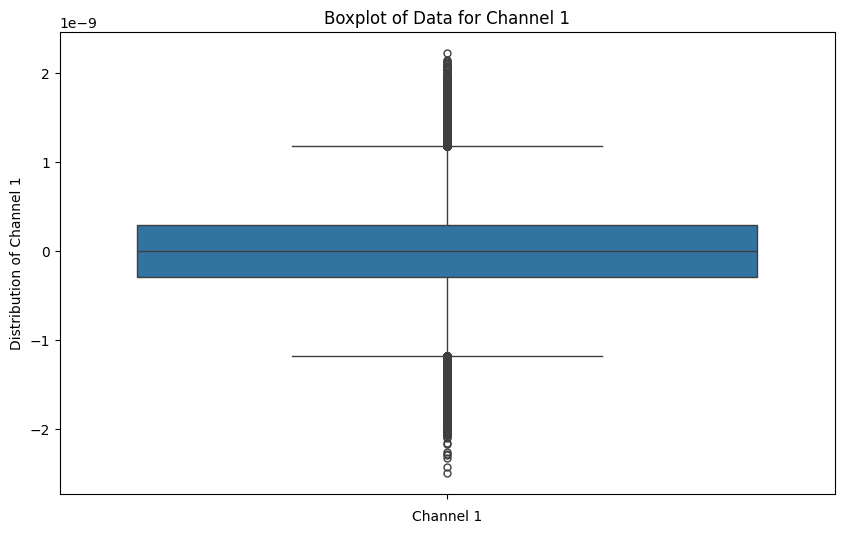

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=channel1_data_numpy_flat, fliersize=5)
plt.title('Boxplot of Data for Channel 1' )
plt.xlabel('Channel 1')
plt.ylabel('Distribution of Channel 1')
plt.show()

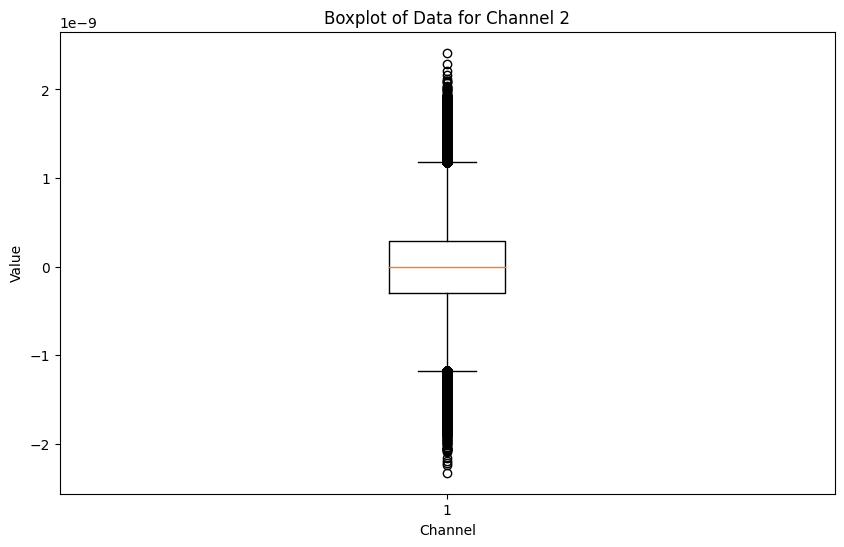

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(channel2_data_numpy_flat)
plt.title('Boxplot of Data for Channel 2' )
plt.xlabel('Channel')
plt.ylabel('Value')
plt.show()

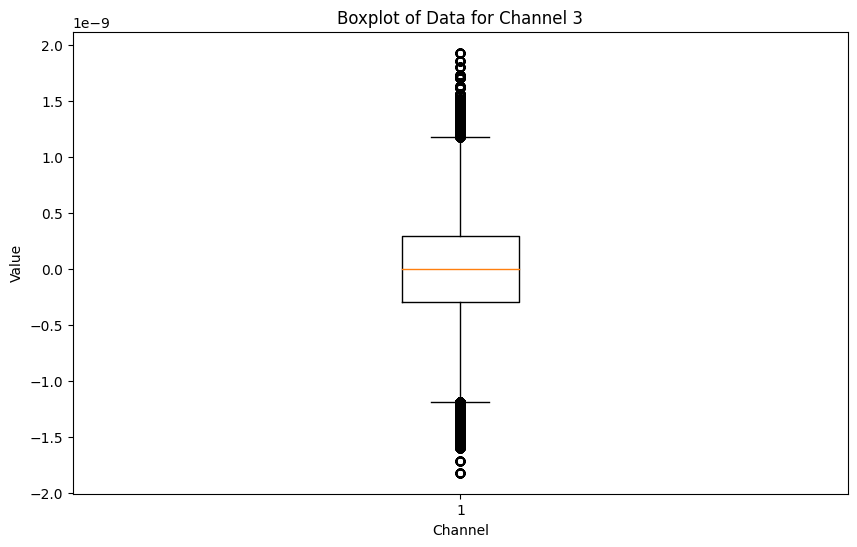

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(channel3_data_numpy_flat)
plt.title('Boxplot of Data for Channel 3' )
plt.xlabel('Channel')
plt.ylabel('Value')
plt.show()

A dataloader class

In [ ]:
class TensorsDataset(torch.utils.data.Dataset):
    def __init__(self, data_tensor, target_tensor=None, transforms=None, target_transforms=None):
        if target_tensor is not None:
            assert data_tensor.size(0) == target_tensor.size(0)
        self.data_tensor = data_tensor
        self.target_tensor = target_tensor

        if transforms is None:
            transforms = []
        if target_transforms is None:
            target_transforms = []

        if not isinstance(transforms, list):
            transforms = [transforms]
        if not isinstance(target_transforms, list):
            target_transforms = [target_transforms]

        self.transforms = transforms
        self.target_transforms = target_transforms

    def __getitem__(self, index):

        data_tensor = self.data_tensor[index]
        for transform in self.transforms:
            data_tensor = transform(data_tensor)

        if self.target_tensor is None:
            return data_tensor

        target_tensor = self.target_tensor[index]
        for transform in self.target_transforms:
            target_tensor = transform(target_tensor)

        return data_tensor, target_tensor

    def __len__(self):
        return self.data_tensor.size(0)


**According to the authors of the paper titled *"POViT: Vision Transformer for Multi-Objective Design and
Characterization of Photonic Crystal Nanocavities"* the gaussian distribution of the 3 channels were: mean value of -8.7270e-13, 3.3969e-13, -1.6978e-12 for dx, dy and dz respectively. The standard deviation being 5e-10 for each channel**

In [ ]:
transformer = transforms.Normalize(mean=[-8.7270e-13, 3.3969e-13, -1.6978e-12],
                                   std=[0.0000000005, 0.0000000005, 0.0000000005])

In [ ]:
dataset = TensorsDataset(input_tensor, output_tensor, transforms=transformer)

In [ ]:
n_epochs = 300
batch_size_train = 64
batch_size_test = 100
learning_rate = 0.01
momentum = 0.5
L2reg = 0.001
log_interval = 10
random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

In [ ]:
#split into training and test datasets

train_size = int(0.8 * len(dataset)) #10,000 data of the total sample for training
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

#loading the data
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test, shuffle=True)


In [ ]:
import time


In [ ]:
fc_training_time = []
depth_training_time = []

**This is the LRS-RCNN architecuture applied by the authors of the paper, Smart and Rapid Design of Nanophotonic Structures by an Adaptive and Regularized Deep Neural Network". Recraeted for calculating the parameter size**

In [ ]:
class PaperNet(nn.Module):
    def __init__(self):
        super(PaperNet,self).__init__()
        self.conv1 = nn.Conv2d(3,20, kernel_size=(3,3), padding = 1, bias=False)
        self.conv2 = nn.Conv2d(20,40,kernel_size=(3,3),bias=False)
        self.fc1 = nn.Linear(240,120)
        self.fc2 = nn.Linear(120,50)
        self.fc3 = nn.Linear(50,2)
    def forward(self,x):
        x = F.relu(F.avg_pool2d(self.conv1(x),(1,2)))

        x = F.relu(F.avg_pool2d(self.conv2(x),(1,2)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

network1 = PaperNet()

In [ ]:
### Using Proper 2 depthwise and pointwise filters



class DepthWiseSepNet2_proper(nn.Module):
  def __init__(self):
    super(DepthWiseSepNet2_proper, self).__init__()
    self.depth1 = nn.Conv2d(3, 3, kernel_size=(3,3), groups=3, padding=1, bias=False)
    self.point1 = nn.Conv2d(3, 20, kernel_size=(1,1), bias=False)
    self.depth2 = nn.Conv2d(20, 20, kernel_size=(3,3), groups=10, bias=False)
    self.point2 = nn.Conv2d(20, 40, kernel_size=(1,1),bias=False)
    self.fc1 = nn.Linear(600, 350)
    self.fc2 = nn.Linear(350, 150)
    self.fc3 = nn.Linear(150, 80)
    self.fc4 = nn.Linear(80, 50)
    self.fc5 = nn.Linear(50, 2)

    self.bn1 = nn.BatchNorm2d(3)
    self.bn2 = nn.BatchNorm2d(20)
    self.bn3 = nn.BatchNorm2d(20)
    self.bn4 = nn.BatchNorm2d(40)

  def forward(self, x):
    x = F.relu(self.bn1(self.depth1(x)))

    x = F.relu(self.bn2(self.point1(x)))

    x = F.relu(self.bn3(self.depth2(x)))

    x = F.relu(F.avg_pool2d((self.bn4(self.point2(x))),(1,2)))


    x = torch.flatten(x, 1)

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x)
    return x

network3 = DepthWiseSepNet2_proper()

**First architecture of thesis where 4 fullyconnected hidden layers are used consisting nodes of size 180. 120, 80 and 50 respectively. Rectified linear unit (ReLU) is used as the activation function on the first 3 layers.**

In [ ]:
class MyNet(nn.Module):
  def __init__(self):
    super(MyNet, self).__init__()
    self.fc1 = nn.Linear(180, 120)
    self.fc2 = nn.Linear(120, 80)
    self.fc3 = nn.Linear(80, 50)
    self.fc4 = nn.Linear(50, 2)

  def forward(self, x):
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x)
    return x


network2 = MyNet()

**This is the second architecture where 2 depthwise separable convolution layers are used where average pooling and batch normalization is used for each 3x3 depthwise and 1x1 pointwise kernel**

In [ ]:
optimizer2 = optim.SGD(network2.parameters(), lr=learning_rate,
                      momentum=momentum, weight_decay=L2reg)

In [ ]:
optimizer3 = optim.SGD(network3.parameters(), lr=learning_rate,
                      momentum=momentum, weight_decay=L2reg)

In [ ]:
train_losses = []  #for Q
trainV_losses = [] #for V
test_losses = [] #for Q
testV_losses = [] #for V
train_output = [] #for Q
trainV_output = [] #for V
train_target = [] #for Q
trainV_target = [] #for V
test_output = []
testV_output = []
test_target = []
testV_target = []

In [ ]:
# train loop
def train(epoch, architecture, opt):



    architecture.train()
    for batch_idx, (data, target) in enumerate(train_loader):

        opt.zero_grad()

        output = architecture(data)
        #Save the training result
        #Q
        train_output.append(output.data[:,0])
        train_target.append(target.data[:,0])
        #V
        trainV_output.append(output.data[:,1])
        trainV_target.append(target.data[:,1])
        #MSE loss
        Q_loss = F.mse_loss(output[:,0],target[:,0])
        V_loss = F.mse_loss(output[:,1],target[:,1])
        loss = Q_loss + 10*V_loss
        #calculate the gradient
        loss.backward()
        opt.step()


        #gradually print epoch results
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{}]\tQloss:{:.6f}\tVloss:{:.6f}\tQ_NN: {:.4f}\tV_NN: {:.4f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                Q_loss.item(), V_loss.item(), output[-1,0], output[-1,1]))
            #store training results
            train_losses.append(Q_loss.item())
            trainV_losses.append(V_loss.item())


            for param_group in opt.param_groups:
                print("Current learning rate: {}".format(param_group['lr']))




**Training and Testing Network 2 (MyNet)**

In [ ]:
### Training using network 2(MyNet):
start_time = time.time()
for epoch in range(1, 301):
    train(epoch, network3, optimizer3)

end_time = time.time()
total_time = end_time - start_time
depth_training_time.append(total_time)

Streaming output truncated to the last 5000 lines.
Train Epoch: 144 [7680/10000]	Qloss:0.000736	Vloss:0.000321	Q_NN: 5.4938	V_NN: 0.9037
Current learning rate: 0.01
Train Epoch: 144 [8320/10000]	Qloss:0.000798	Vloss:0.000984	Q_NN: 5.4630	V_NN: 0.8830
Current learning rate: 0.01
Train Epoch: 144 [8960/10000]	Qloss:0.000711	Vloss:0.000612	Q_NN: 5.5725	V_NN: 0.9555
Current learning rate: 0.01
Train Epoch: 144 [9600/10000]	Qloss:0.000534	Vloss:0.000572	Q_NN: 5.3922	V_NN: 1.0252
Current learning rate: 0.01
Train Epoch: 145 [0/10000]	Qloss:0.000739	Vloss:0.001478	Q_NN: 5.2720	V_NN: 0.9825
Current learning rate: 0.01
Train Epoch: 145 [640/10000]	Qloss:0.000814	Vloss:0.000581	Q_NN: 5.6178	V_NN: 0.9158
Current learning rate: 0.01
Train Epoch: 145 [1280/10000]	Qloss:0.000914	Vloss:0.000250	Q_NN: 5.5858	V_NN: 0.8304
Current learning rate: 0.01
Train Epoch: 145 [1920/10000]	Qloss:0.000689	Vloss:0.000320	Q_NN: 5.3998	V_NN: 0.9737
Current learning rate: 0.01
Train Epoch: 145 [2560/10000]	Qloss:0.000

In [ ]:
fc_training_time

[451.0398008823395,
 443.1194200515747,
 445.2064781188965,
 436.7561354637146,
 445.1066131591797]

In [ ]:
depth_training_time

[1304.4704434871674, 1288.2294154167175]

In [ ]:
print(f'Minimum Q-factor loss when trainig Network4: {min(train_losses):.5f}')
print(f'Minimum V loss when trainig Network4: {min(trainV_losses):.5f}')

Minimum Q-factor loss when trainig Network4: 0.00026
Minimum V loss when trainig Network4: 0.00019


In [ ]:
print(f'Minimum Q-factor loss when trainig Network5: {min(train_losses):.5f}')
print(f'Minimum V loss when trainig Network5: {min(trainV_losses):.5f}')

Minimum Q-factor loss when trainig Network5: 0.00021
Minimum V loss when trainig Network5: 0.00022


In [ ]:
print(f'Minimum Q-factor loss when trainig Network3: {min(train_losses):.5f}')
print(f'Minimum V loss when trainig Network3: {min(trainV_losses):.5f}')

Minimum Q-factor loss when trainig Network3: 0.00022
Minimum V loss when trainig Network3: 0.00005


In [ ]:
num = sum(p.numel() for p in network3.parameters() if p.requires_grad)
print(f'Amount of parameters needed for training the network3(proper depthwise conv): {num}')

Amount of parameters needed for training the network3(proper depthwise conv): 280645


In [ ]:
def test():
    #global test_output
    network2.eval()
    test_loss = 0
    testV_loss = 0
    with torch.no_grad(): #disable the gradient computation
        for data, target in test_loader:
            output = network2(data)
            #save the test result
            #Q
            test_output.append(output[:,0])
            test_target.append(target[:,0])
            #V
            testV_output.append(output[:,1])
            testV_target.append(target[:,1])
            #loss
            test_loss += F.mse_loss(output[:,0], target[:,0], size_average=False).item()
            testV_loss += F.mse_loss(output[:,1], target[:,1], size_average=False).item()

    #calculate the average loss per epoch
    test_loss /= len(test_loader.dataset)
    testV_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    testV_losses.append(testV_loss)
    print('\nTest set: Qloss: {:.6f}, Vloss: {:.6f}, Qn: {:.4f}, Qf: {:.4f}, Vn: {:.4f}, Vf: {:.4f}\n'.format(
                test_loss, testV_loss, output[-1,0], target[-1,0], output[-1,1], target[-1,1]))



    return testV_loss

In [ ]:
Loss = test()

/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Qloss: 0.000472, Vloss: 0.005422, Qn: 5.6142, Qf: 5.5865, Vn: 0.8483, Vf: 0.8401



In [ ]:
print(f'Minimum Q-factor loss when testing Network3: {min(test_losses):.6f}')
print(f'Minimum V loss when testing Network3: {min(testV_losses):.6f}')

Minimum Q-factor loss when testing Network3: 0.000472
Minimum V loss when testing Network3: 0.005422


**Training and testing My Net**

In [ ]:
### Training using network 2(MyNet):

for epoch in range(1, 301):
    train(epoch, network2, optimizer2)

Streaming output truncated to the last 5000 lines.
Train Epoch: 144 [7680/10000]	Qloss:0.000297	Vloss:0.000540	Q_NN: 5.3667	V_NN: 0.9441
Current learning rate: 0.01
Train Epoch: 144 [8320/10000]	Qloss:0.000263	Vloss:0.000552	Q_NN: 5.5226	V_NN: 0.8750
Current learning rate: 0.01
Train Epoch: 144 [8960/10000]	Qloss:0.000355	Vloss:0.000413	Q_NN: 5.6043	V_NN: 0.8541
Current learning rate: 0.01
Train Epoch: 144 [9600/10000]	Qloss:0.000313	Vloss:0.000599	Q_NN: 5.4682	V_NN: 0.9432
Current learning rate: 0.01
Train Epoch: 145 [0/10000]	Qloss:0.000398	Vloss:0.000745	Q_NN: 5.6196	V_NN: 0.9454
Current learning rate: 0.01
Train Epoch: 145 [640/10000]	Qloss:0.000444	Vloss:0.000710	Q_NN: 5.6018	V_NN: 0.8302
Current learning rate: 0.01
Train Epoch: 145 [1280/10000]	Qloss:0.000359	Vloss:0.000670	Q_NN: 5.4347	V_NN: 1.0125
Current learning rate: 0.01
Train Epoch: 145 [1920/10000]	Qloss:0.000354	Vloss:0.000469	Q_NN: 5.5850	V_NN: 0.8618
Current learning rate: 0.01
Train Epoch: 145 [2560/10000]	Qloss:0.000

In [ ]:
print(f'Minimum Q-factor loss when trainig Network2: {min(train_losses):.5f}')
print(f'Minimum V loss when trainig Network2: {min(trainV_losses):.5f}')

Minimum Q-factor loss when trainig Network2: 0.00010
Minimum V loss when trainig Network2: 0.00010


In [ ]:
num1 = sum(p.numel() for p in network2.parameters() if p.requires_grad)
print(f'Amount of parameters needed for training the network: {num1}')

Amount of parameters needed for training the network: 35552


In [ ]:
print(f'Percentage of parameters less needed for my network compared to the papaers network is : {(num-num1)/num *100}%')

Percentage of parameters less needed for my network compared to the papaers network is : 16.95786228160329%


In [ ]:
def test1():
    #global test_output
    net.eval()
    test_loss = 0
    testV_loss = 0
    with torch.no_grad(): #disable the gradient computation
        for data, target in test_loader:
            output = net(data)
            #save the test result
            #Q
            test_output.append(output[:,0])
            test_target.append(target[:,0])
            #V
            testV_output.append(output[:,1])
            testV_target.append(target[:,1])
            #loss
            test_loss += F.mse_loss(output[:,0], target[:,0], size_average=False).item()
            testV_loss += F.mse_loss(output[:,1], target[:,1], size_average=False).item()

    #calculate the average loss per epoch
    test_loss /= len(test_loader.dataset)
    testV_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    testV_losses.append(testV_loss)
    print('\nTest set: Qloss: {:.6f}, Vloss: {:.6f}, Qn: {:.4f}, Qf: {:.4f}, Vn: {:.4f}, Vf: {:.4f}\n'.format(
                test_loss, testV_loss, output[-1,0], target[-1,0], output[-1,1], target[-1,1]))



    return testV_loss

In [ ]:
Loss = test1()

/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Qloss: 0.000472, Vloss: 0.005422, Qn: 5.5489, Qf: 5.5149, Vn: 0.8457, Vf: 0.8407



In [ ]:
print(f'Minimum Q-factor loss when testing Network2: {min(test_losses):.6f}')
print(f'Minimum V loss when testing Network2: {min(testV_losses):.6f}')

Minimum Q-factor loss when testing Network2: 0.000263
Minimum V loss when testing Network2: 0.003450


**Saving the model**

In [ ]:
path = './network3_depthwise_proper.pth'
#torch.save(network3.state_dict(), path)

In [ ]:
net = DepthWiseSepNet2_proper()
net.load_state_dict(torch.load(path))

<All keys matched successfully>

**Calculation of error prediction**

In [ ]:
## Concatinating list of tensors into a single tensor

test_output = torch.cat(test_output, dim=0)
testV_output = torch.cat(testV_output, dim=0)
test_target = torch.cat(test_target, dim=0)
testV_target = torch.cat(testV_target, dim=0)

In [ ]:
## Converting the tensor data into numpy arrays for easy calculation

test_output_num = test_output.numpy()
testV_output_num = testV_output.numpy()
test_target_num = test_target.numpy()
testV_target_num = testV_target.numpy()



In [ ]:
# A function to calculate the error percentage of predicted values


def percentage_error_pred(pred_array, target_array):
  error_list = []
  for i in zip(pred_array, target_array):
    temp = np.absolute(np.subtract(i[0],i[1]))
    temp = (temp/i[1]) * 100
    error_list.append(temp)
  return error_list



In [ ]:
### Calculating Q-factor error for test data:

q_error_list = percentage_error_pred(test_output_num, test_target_num)

In [ ]:
print(f'Minimum values from the Q-factor percentage error prdiction for FC architecture: {min(q_error_list):.5f}%')
print(f'Average values from the Q-factor percentage error prdiction for FC architecture: {sum(q_error_list)/len(q_error_list):.5f}%')
print(f'Maximum values from the Q-factor percentage error prdiction for FC architecture: {max(q_error_list):.5f}%')



Minimum values from the Q-factor percentage error prdiction for FC architecture: 0.00014%
Average values from the Q-factor percentage error prdiction for FC architecture: 0.21993%
Maximum values from the Q-factor percentage error prdiction for FC architecture: 1.77352%


In [ ]:
print(f'Minimum values from the Q-factor percentage error prdiction for Depthwise Separable Convolution architecture: {min(q_error_list):.5f}%')
print(f'Average values from the Q-factor percentage error prdiction for Depthwise Separable Convolution architecture: {sum(q_error_list)/len(q_error_list):.5f}%')
print(f'Maximum values from the Q-factor percentage error prdiction for Depthwise Separable Convolution architecture: {max(q_error_list):.5f}%')



Minimum values from the Q-factor percentage error prdiction for Depthwise Separable Convolution architecture: 0.00041%
Average values from the Q-factor percentage error prdiction for Depthwise Separable Convolution architecture: 0.34044%
Maximum values from the Q-factor percentage error prdiction for Depthwise Separable Convolution architecture: 2.39971%


In [ ]:
print(f'Minimum values from the Q-factor percentage error prdiction for proper Depthwise Separable Convolution architecture: {min(q_error_list):.5f}%')
print(f'Average values from the Q-factor percentage error prdiction for proper Depthwise Separable Convolution architecture: {sum(q_error_list)/len(q_error_list):.5f}%')
print(f'Maximum values from the Q-factor percentage error prdiction for proper Depthwise Separable Convolution architecture: {max(q_error_list):.5f}%')



Minimum values from the Q-factor percentage error prdiction for proper Depthwise Separable Convolution architecture: 0.00076%
Average values from the Q-factor percentage error prdiction for proper Depthwise Separable Convolution architecture: 0.29332%
Maximum values from the Q-factor percentage error prdiction for proper Depthwise Separable Convolution architecture: 2.31294%


In [ ]:
### Calculating V error for test data:

v_error_list = percentage_error_pred(testV_output_num, testV_target_num)


In [ ]:
print(f'Minimum values from the V error prdiction for FC architecture: {min(v_error_list):.5f}%')
print(f'Average values from the V error prdiction for FC architecture: {sum(v_error_list)/len(q_error_list):.5f}%')
print(f'Maximum values from the V error prdiction for FC architecture: {max(v_error_list):.5f}%')


Minimum values from the V error prdiction for FC architecture: 0.00038%
Average values from the V error prdiction for FC architecture: 4.46376%
Maximum values from the V error prdiction for FC architecture: 30.87249%


In [ ]:
print(f'Minimum values from the V error prdiction for proper Depthwise Separable Convolution architecture: {min(v_error_list):.5f}%')
print(f'Average values from the V error prdiction for proper Depthwise Separable Convolution architecture: {sum(v_error_list)/len(q_error_list):.5f}%')
print(f'Maximum values from the V error prdiction for proper Depthwise Separable Convolution architecture: {max(v_error_list):.5f}%')


Minimum values from the V error prdiction for proper Depthwise Separable Convolution architecture: 0.01211%
Average values from the V error prdiction for proper Depthwise Separable Convolution architecture: 5.92464%
Maximum values from the V error prdiction for proper Depthwise Separable Convolution architecture: 33.48797%


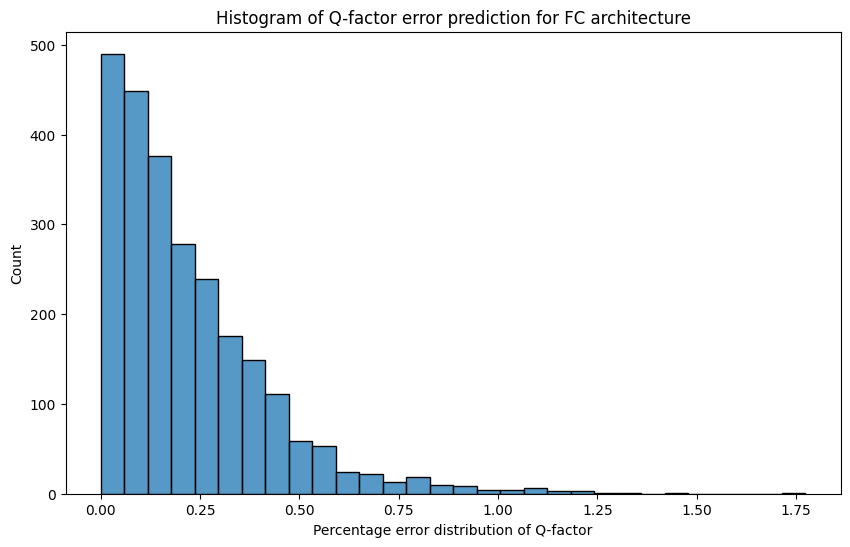

In [ ]:
q_error_numpy = np.array(q_error_list)
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=q_error_numpy, bins=30)
plt.title('Histogram of Q-factor error prediction for FC architecture')
plt.xlabel('Percentage error distribution of Q-factor')
plt.ylabel('Count')
plt.show()

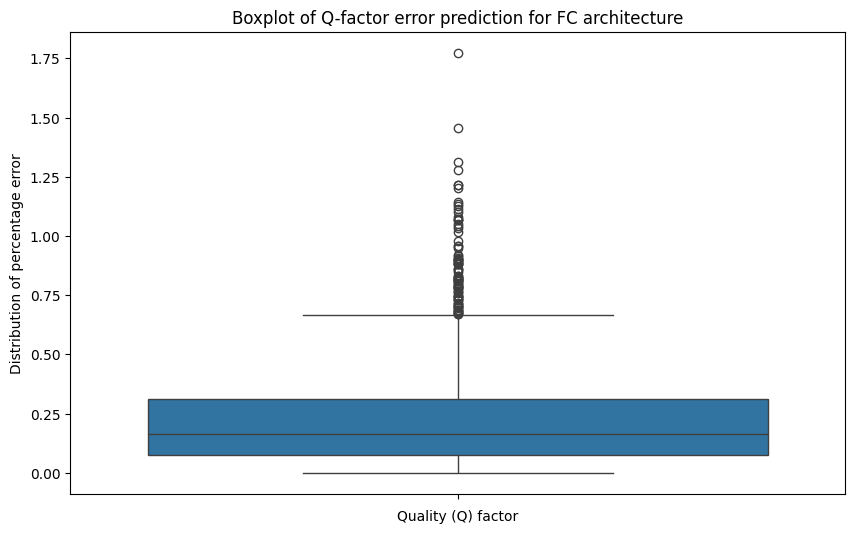

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=q_error_numpy)
plt.title('Boxplot of Q-factor error prediction for FC architecture' )
plt.xlabel('Quality (Q) factor')
plt.ylabel('Distribution of percentage error')
plt.show()

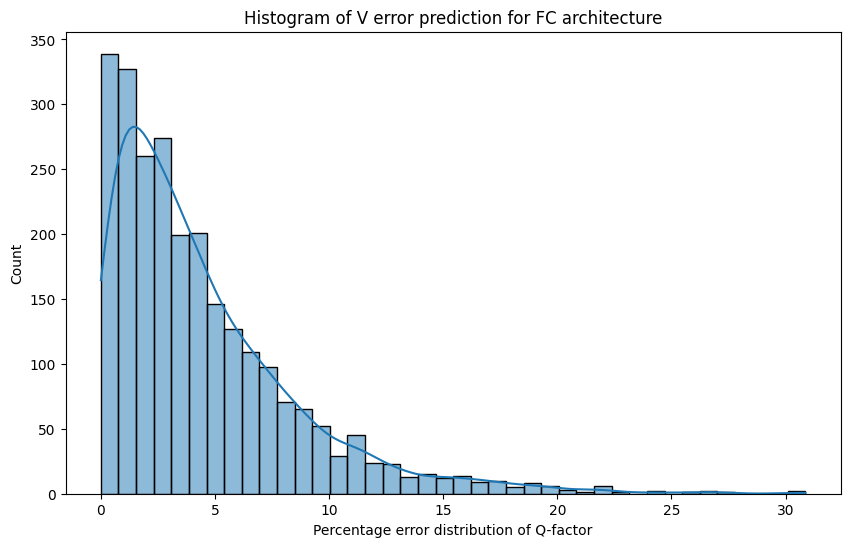

In [ ]:
v_error_numpy = np.array(v_error_list)
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=v_error_numpy, bins=40, kde=True)
plt.title('Histogram of V error prediction for FC architecture')
plt.xlabel('Percentage error distribution of Q-factor')
plt.ylabel('Count')
plt.show()

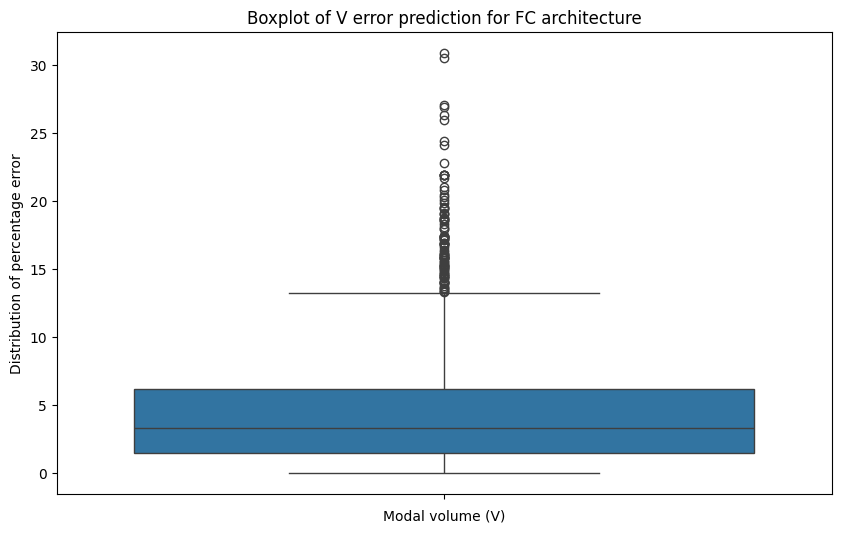

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=v_error_numpy)
plt.title('Boxplot of V error prediction for FC architecture' )
plt.xlabel('Modal volume (V)')
plt.ylabel('Distribution of percentage error')
plt.show()

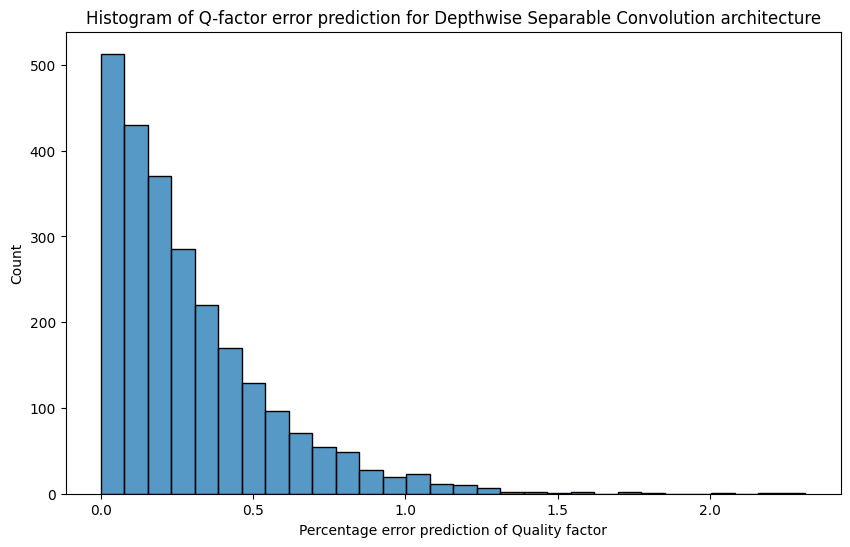

In [ ]:
q_error_numpy = np.array(q_error_list)
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=q_error_numpy, bins=30)
plt.title('Histogram of Q-factor error prediction for Depthwise Separable Convolution architecture')
plt.xlabel('Percentage error prediction of Quality factor')
plt.ylabel('Count')
plt.show()

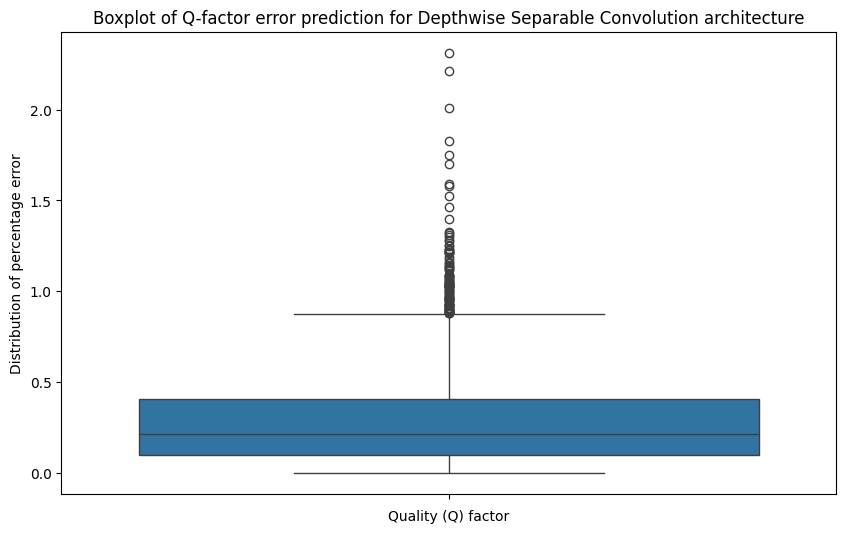

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=q_error_numpy)
plt.title('Boxplot of Q-factor error prediction for Depthwise Separable Convolution architecture' )
plt.xlabel('Quality (Q) factor')
plt.ylabel('Distribution of percentage error')
plt.show()

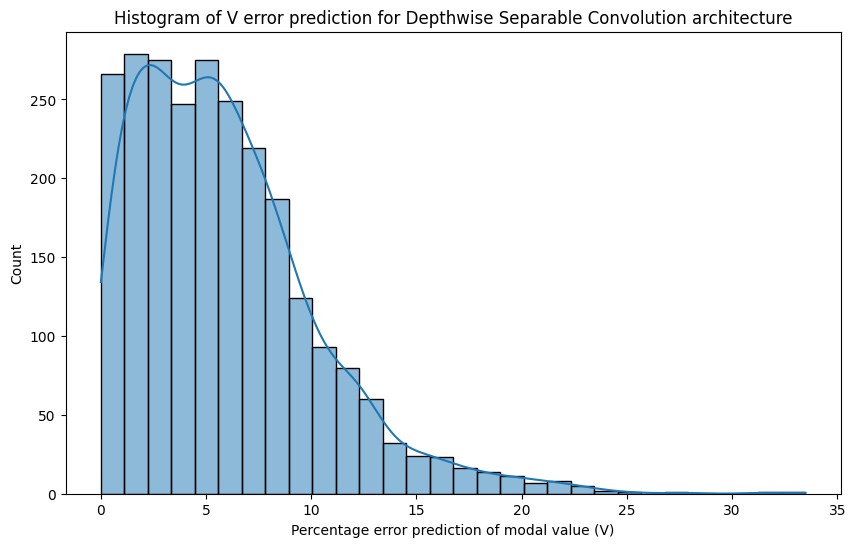

In [ ]:
v_error_numpy = np.array(v_error_list)
# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=v_error_numpy, bins=30, kde=True)
plt.title('Histogram of V error prediction for Depthwise Separable Convolution architecture')
plt.xlabel('Percentage error prediction of modal value (V)')
plt.ylabel('Count')
plt.show()

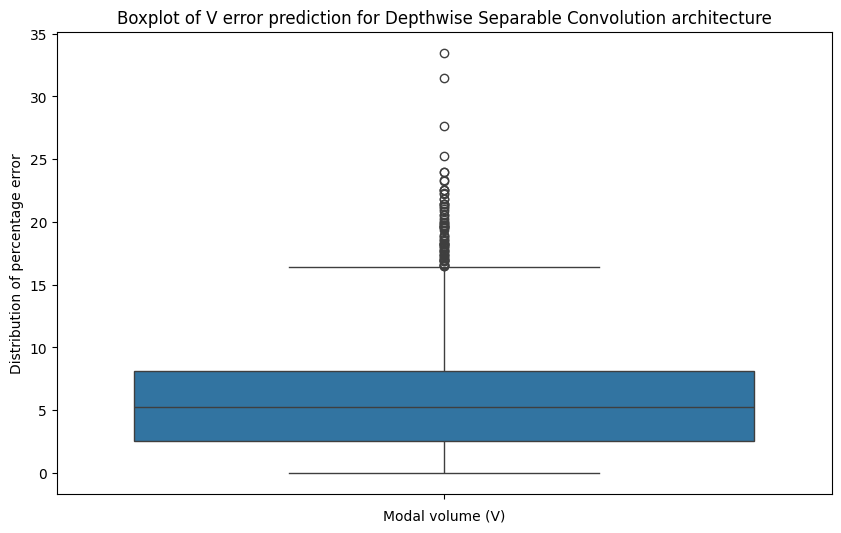

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=v_error_numpy)
plt.title('Boxplot of V error prediction for Depthwise Separable Convolution architecture' )
plt.xlabel('Modal volume (V)')
plt.ylabel('Distribution of percentage error')
plt.show()

In [ ]:
### Pearson Correlation Coefficient Calculation

def pearson_coeff(pred_array, target_array):
  pred_mean = np.mean(pred_array)
  target_mean = np.mean(target_array)


  nominator = np.sum((pred_array - pred_mean) * (target_array - target_mean))
  denominator = np.sqrt(np.sum((pred_array - pred_mean) **2)  * np.sum((target_array - target_mean) **2))

  coeff = nominator/denominator

  return coeff



In [ ]:
### Pearson Coeff of Q-factor:
q_coeff = pearson_coeff(test_output_num, test_target_num) * 100
print(f'Pearson coefficinet of Q-factor for FC architecture is {q_coeff:.5f}%')

Pearson coefficinet of Q-factor for FC architecture is 98.89314%


In [ ]:
### Pearson Coeff of Q-factor:
q_coeff = pearson_coeff(test_output_num, test_target_num) * 100
print(f'Pearson coefficinet of Q-factor for proper Depthwise Separable Convolution architecture is {q_coeff:.5f}%')

Pearson coefficinet of Q-factor for proper Depthwise Separable Convolution architecture is 97.99995%


In [ ]:
### Pearson Coeff of V:
v_coeff = pearson_coeff(testV_output_num, testV_target_num) * 100
print(f'Pearson coefficinet of V for FC architecture is {v_coeff:.5f}%')

Pearson coefficinet of V is 71.76899%


Pearson coefficinet of V for Depthwise Separable Convolution architecture is 65.47571%


In [ ]:
### Pearson Coeff of V:
v_coeff = pearson_coeff(testV_output_num, testV_target_num) * 100
print(f'Pearson coefficinet of V for proper Depthwise Separable Convolution architecture is {v_coeff:.5f}%')

Pearson coefficinet of V for proper Depthwise Separable Convolution architecture is 68.13968%


**We can see that from comparing with the Paper Network and the POViT network our network has far less parameters while maintaining the same level of Minimum Q and V MSE loss**

**In terms of parameters, our network has about
16.95786% less parameters than the paper's network while decreasining the minimum Q-factor loss by 15% while only increasing the V loss by about 10%**

**Also when comparing to the very complex POViT architecture, our architecture is very close in Q and V loss accuracy while significantly decreasing computation time. Ours only needed on average about 6 mins on a 8Gb, Intel(R) Core(TM) i5-2450M CPU @ 2.50GHz processor while the POViT took 18-20 mins on average that too using an Nvidia
GeForce RTX3070 GPU and 16G memory**

In [ ]:
### Only taking Q values

q_only_output = torch.cat([output_tensor[:, :1]], dim=1)

In [ ]:
q_only_output.shape

torch.Size([12500, 1])

In [ ]:
dataset_q_only = TensorsDataset(input_tensor, q_only_output, transforms=transformer)

In [ ]:
#split into training and test datasets

train_size = int(0.8 * len(dataset_q_only)) #10,000 data of the total sample for training
test_size = len(dataset_q_only) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset_q_only, [train_size, test_size])

#loading the data
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test, shuffle=True)


In [ ]:
# train loop
def trainq(epoch, architecture, opt):



    architecture.train()
    for batch_idx, (data, target) in enumerate(train_loader):

        opt.zero_grad()

        output = architecture(data)

        #Q
        train_output.append(output.data[:,0])
        train_target.append(target.data[:,0])

        Q_loss = F.mse_loss(output[:,0],target[:,0])

        loss = Q_loss
        #calculate the gradient
        loss.backward()
        opt.step()


        #gradually print epoch results
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{}]\tQloss:{:.6f}\tQ_NN: {:.4f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                Q_loss.item(),  output[-1,0]))
            #store training results
            train_losses.append(Q_loss.item())

            train_counter.append(
                (batch_idx*batch_size_train) + ((epoch-1)*len(train_loader.dataset)))

            for param_group in opt.param_groups:
                print("Current learning rate: {}".format(param_group['lr']))




In [ ]:
for i in range(1, n_epochs+1):
  trainq(i, network2, optimizer2)

Streaming output truncated to the last 5000 lines.
Train Epoch: 144 [7680/10000]	Qloss:0.000246	Q_NN: 5.4412
Current learning rate: 0.01
Train Epoch: 144 [8320/10000]	Qloss:0.000202	Q_NN: 5.3287
Current learning rate: 0.01
Train Epoch: 144 [8960/10000]	Qloss:0.000312	Q_NN: 5.5824
Current learning rate: 0.01
Train Epoch: 144 [9600/10000]	Qloss:0.000194	Q_NN: 5.5182
Current learning rate: 0.01
Train Epoch: 145 [0/10000]	Qloss:0.000243	Q_NN: 5.5972
Current learning rate: 0.01
Train Epoch: 145 [640/10000]	Qloss:0.000183	Q_NN: 5.5995
Current learning rate: 0.01
Train Epoch: 145 [1280/10000]	Qloss:0.000259	Q_NN: 5.4701
Current learning rate: 0.01
Train Epoch: 145 [1920/10000]	Qloss:0.000196	Q_NN: 5.6428
Current learning rate: 0.01
Train Epoch: 145 [2560/10000]	Qloss:0.000274	Q_NN: 5.4187
Current learning rate: 0.01
Train Epoch: 145 [3200/10000]	Qloss:0.000200	Q_NN: 5.5766
Current learning rate: 0.01
Train Epoch: 145 [3840/10000]	Qloss:0.000254	Q_NN: 5.4200
Current learning rate: 0.01
Train E

In [ ]:
print(f'Minimum Q-factor loss when trainig Network4: {min(train_losses):.5f}')

Minimum Q-factor loss when trainig Network4: 0.00084


In [ ]:
def testq():
    #global test_output
    network2.eval()
    test_loss = 0

    with torch.no_grad(): #disable the gradient computation
        for data, target in test_loader:
            output = network2(data)
            #save the test result
            #Q
            test_output.append(output[:,0])
            test_target.append(target[:,0])

            #loss
            test_loss += F.mse_loss(output[:,0], target[:,0], size_average=False).item()


    #calculate the average loss per epoch
    test_loss /= len(test_loader.dataset)

    test_losses.append(test_loss)

    print('\nTest set: Qloss: {:.6f}, Qn: {:.4f}, Qf: {:.4f}\n'.format(
                test_loss, output[-1,0], target[-1,0]))



    return test_loss

In [ ]:
Loss = testq()

/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Qloss: 0.000240, Qn: 5.5749, Qf: 5.5733



In [ ]:
print(f'Minimum Q-factor loss when testing FC network when only Q-factor is used for loss calculation is available: {min(test_losses):.6f}')

Minimum Q-factor loss when testing FC network when only Q-factor is used for loss calculation is available: 0.000240


In [ ]:
test_output = torch.cat(test_output, dim=0)
test_target = torch.cat(test_target, dim=0)


In [ ]:
test_output_num = test_output.numpy()
test_target_num = test_target.numpy()


In [ ]:
q_error_list = percentage_error_pred(test_output_num, test_target_num)
print(f'Minimum values from the Q-factor percentage error prdiction for FC network (when only Q-factor is used in loss function): {min(q_error_list):.5f}%')
print(f'Average values from the Q-factor percentage error prdiction for FC network (when only Q-factor is used in loss function): {sum(q_error_list)/len(q_error_list):.5f}%')
print(f'Maximum values from the Q-factor percentage error prdiction for FC network (when only Q-factor is used in loss function): {max(q_error_list):.5f}%')

Minimum values from the Q-factor percentage error prdiction for FC network (when only Q-factor is used in loss function): 0.00016%
Average values from the Q-factor percentage error prdiction for FC network (when only Q-factor is used in loss function): 0.21326%
Maximum values from the Q-factor percentage error prdiction for FC network (when only Q-factor is used in loss function): 1.75449%


In [ ]:
q_coeff = pearson_coeff(test_output_num, test_target_num) * 100
print(f'Pearson coefficinet of Q-factor for FC netowrk when only Q-factor is used in loss calculation {q_coeff:.5f}%')

Pearson coefficinet of Q-factor for FC netowrk when only Q-factor is used in loss calculation 99.00199%


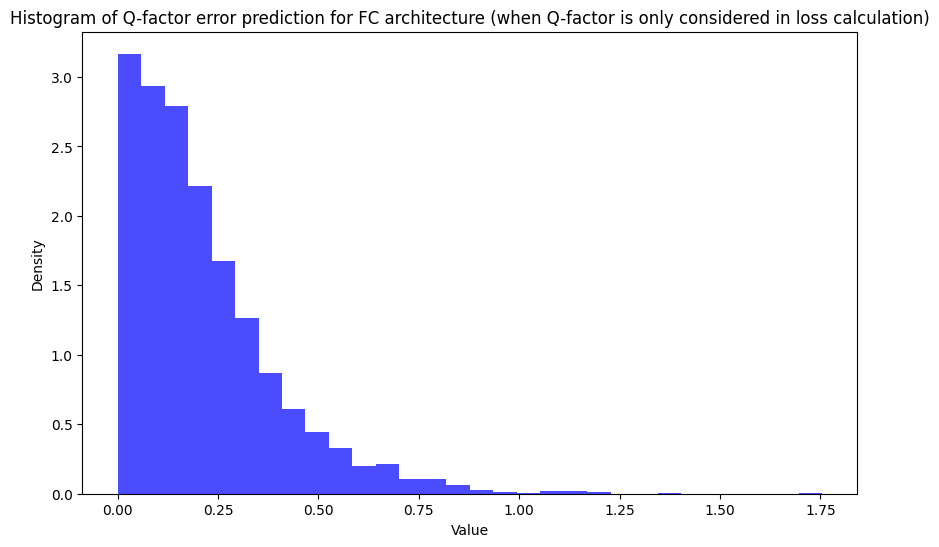

In [ ]:
q_error_numpy = np.array(q_error_list)
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(q_error_numpy, bins=30, density=True, alpha=0.7, color='b')
plt.title('Histogram of Q-factor error prediction for FC architecture (when Q-factor is only considered in loss calculation)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

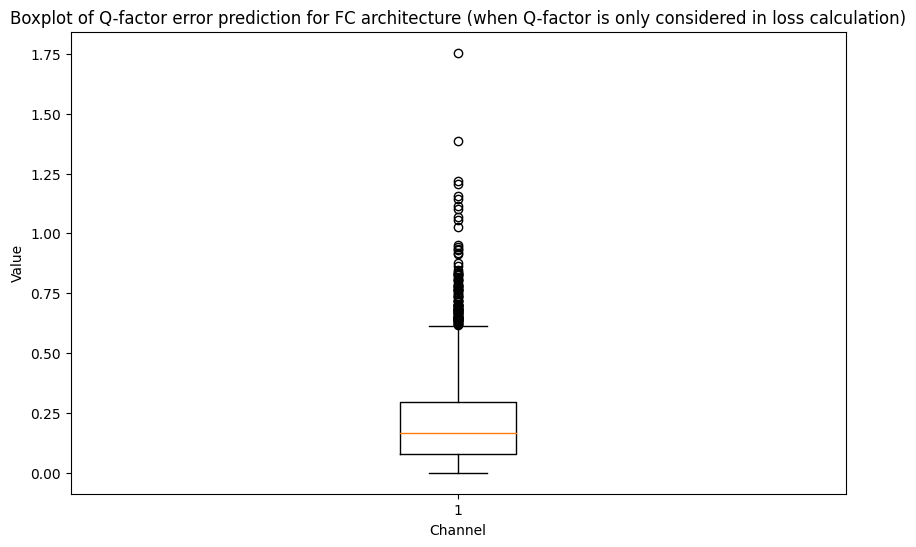

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(q_error_numpy)
plt.title('Boxplot of Q-factor error prediction for FC architecture (when Q-factor is only considered in loss calculation)' )
plt.xlabel('Channel')
plt.ylabel('Value')
plt.show()

In [ ]:
v_only_output = torch.cat([output_tensor[:, 1:]], dim=1)

In [ ]:
dataset_v_only = TensorsDataset(input_tensor, v_only_output, transforms=transformer)

In [ ]:
#split into training and test datasets

train_size = int(0.8 * len(dataset_v_only)) #10,000 data of the total sample for training
test_size = len(dataset_v_only) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset_v_only, [train_size, test_size])

#loading the data
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test, shuffle=True)


In [ ]:
# train loop
def trainv(epoch, architecture, opt):



    architecture.train()
    for batch_idx, (data, target) in enumerate(train_loader):

        opt.zero_grad()

        output = architecture(data)

        #V
        trainV_output.append(output.data[:, 0])
        trainV_target.append(target.data[:, 0])
        #MSE loss

        V_loss = F.mse_loss(output[:, 0],target[:, 0])
        loss = 10*V_loss
        #calculate the gradient
        loss.backward()
        opt.step()


        #gradually print epoch results
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{}]\tVloss:{:.6f}\tV_NN: {:.4f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                 V_loss.item(), output[-1,0]))
            #store training results

            trainV_losses.append(V_loss.item())
            train_counter.append(
                (batch_idx*batch_size_train) + ((epoch-1)*len(train_loader.dataset)))

            for param_group in opt.param_groups:
                print("Current learning rate: {}".format(param_group['lr']))




In [ ]:
for i in range(1, n_epochs+1):
  trainv(i, network2, optimizer2)

Streaming output truncated to the last 5000 lines.
Train Epoch: 144 [7680/10000]	Vloss:0.000462	V_NN: 0.8127
Current learning rate: 0.01
Train Epoch: 144 [8320/10000]	Vloss:0.000609	V_NN: 0.9032
Current learning rate: 0.01
Train Epoch: 144 [8960/10000]	Vloss:0.000447	V_NN: 1.0004
Current learning rate: 0.01
Train Epoch: 144 [9600/10000]	Vloss:0.000569	V_NN: 0.9834
Current learning rate: 0.01
Train Epoch: 145 [0/10000]	Vloss:0.000331	V_NN: 0.9544
Current learning rate: 0.01
Train Epoch: 145 [640/10000]	Vloss:0.000483	V_NN: 0.8650
Current learning rate: 0.01
Train Epoch: 145 [1280/10000]	Vloss:0.000356	V_NN: 0.8589
Current learning rate: 0.01
Train Epoch: 145 [1920/10000]	Vloss:0.000468	V_NN: 0.8544
Current learning rate: 0.01
Train Epoch: 145 [2560/10000]	Vloss:0.000508	V_NN: 0.8993
Current learning rate: 0.01
Train Epoch: 145 [3200/10000]	Vloss:0.000385	V_NN: 0.8879
Current learning rate: 0.01
Train Epoch: 145 [3840/10000]	Vloss:0.000597	V_NN: 0.9402
Current learning rate: 0.01
Train E

In [ ]:
def testv():
    #global test_output
    network2.eval()
    testV_loss = 0

    with torch.no_grad(): #disable the gradient computation
        for data, target in test_loader:
            output = network2(data)
            #save the test result
            #Q
            testV_output.append(output[:,0])
            testV_target.append(target[:,0])

            #loss
            testV_loss += F.mse_loss(output[:,0], target[:,0], size_average=False).item()


    #calculate the average loss per epoch
    testV_loss /= len(test_loader.dataset)

    testV_losses.append(testV_loss)

    print('\nTest set: Vloss: {:.6f}, Vn: {:.4f}, Qf: {:.4f}\n'.format(
                testV_loss, output[-1,0], target[-1,0]))



    return testV_loss

In [ ]:
Loss = testv()

/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Vloss: 0.004001, Vn: 0.8875, Qf: 0.8298



In [ ]:
def percentage_error_pred_v(pred_array, target_array):
  error_list = []
  for i in zip(pred_array, target_array):
    temp = np.absolute(np.subtract(i[0],i[1]))
    temp = (temp/i[1]) * 100
    error_list.append(temp)
  return error_list

In [ ]:
testV_output = torch.cat(testV_output, dim=0)
testV_target = torch.cat(testV_target, dim=0)
testV_output_num = testV_output.numpy()
testV_target_num = testV_target.numpy()

In [ ]:
v_error_list = percentage_error_pred_v(testV_output_num, testV_target_num)
print(f'Minimum values from the V percentage error prdiction for FC network whenonly V considered in loss calculation: {min(v_error_list):.5f}%')
print(f'Average values from the V percentage error prdiction for FC network whenonly V considered in loss calculation: {sum(v_error_list)/len(v_error_list):.5f}%')
print(f'Maximum values from the V percentage error prdiction for FC network whenonly V considered in loss calculation: {max(v_error_list):.5f}%')

Minimum values from the V percentage error prdiction for FC network whenonly V considered in loss calculation: 0.00007%
Average values from the V percentage error prdiction for FC network whenonly V considered in loss calculation: 4.68105%
Maximum values from the V percentage error prdiction for FC network whenonly V considered in loss calculation: 38.18595%


In [ ]:
v_coeff = pearson_coeff(testV_output_num, testV_target_num) * 100
print(f'Pearson coefficinet of V for FC network whenonly V considered in loss calculation is: {v_coeff:.5f}%')

Pearson coefficinet of V for FC network whenonly V considered in loss calculation is: 68.78324%


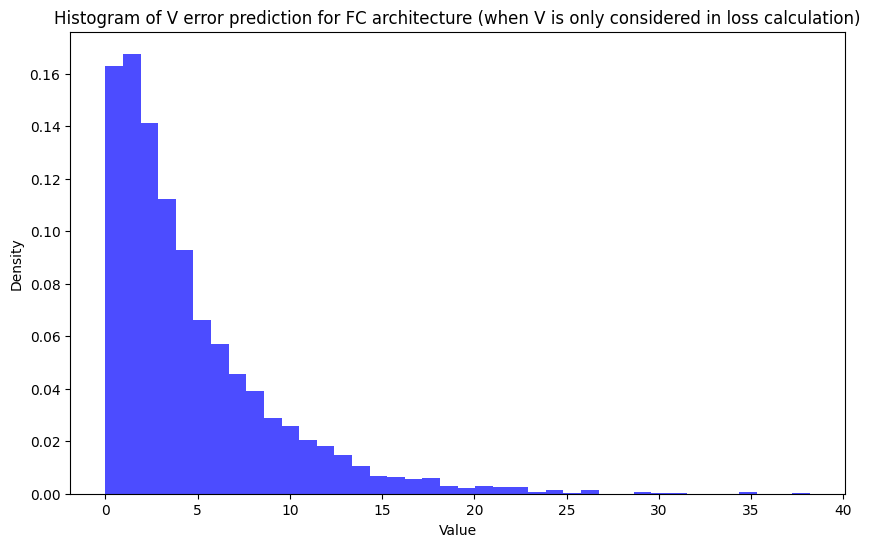

In [ ]:
v_error_numpy = np.array(v_error_list)
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(v_error_numpy, bins=40, density=True, alpha=0.7, color='b')
plt.title('Histogram of V error prediction for FC architecture (when V is only considered in loss calculation)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

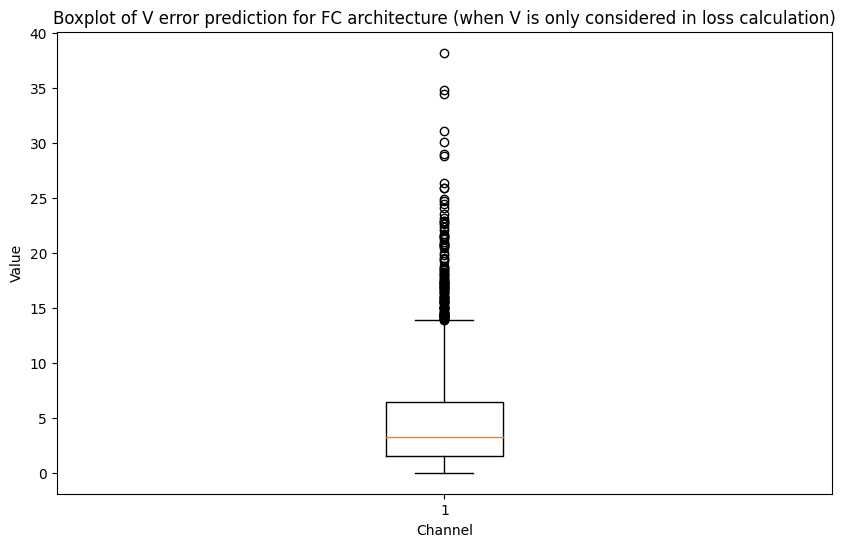

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(v_error_numpy)
plt.title('Boxplot of V error prediction for FC architecture (when V is only considered in loss calculation)' )
plt.xlabel('Channel')
plt.ylabel('Value')
plt.show()